# Feature Engineering & Time Series - Mindestanforderung 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

Laden des Datensatzes aus Mindestanforerdung 2 und mappen der Alters-Spalte auf numerische Werte

In [2]:
df = pd.read_csv("output_woche2.csv")

if "AgeNum" not in df.columns and "Age" in df.columns:
    age_map = {
        'Under 18 years old': 17,
        '18-24 years old': 21,
        '25-34 years old': 29,
        '35-44 years old': 39,
        '45-54 years old': 49,
        '55-64 years old': 59,
        '65 years or older': 70
    }
    df["AgeNum"] = df["Age"].map(age_map)
    df = df[df["AgeNum"] <= 65]

#### Erstellen Sie mindestens 2 neue Features
- Feature 1 - Währung vereinheitlichen und in USD umrechnen
- `Currency` wird auf 3 Zeichen reduziert, sofern es noch andere Werte geben sollte
- einzelne Währungen ausgeschlossen
- `CompTotal` durch CurrencyConverter in USD umgerechner, woraus neues Feature entsteht `ConvertedCompYearly`

Anzahl der jeweiligen Währungen ausgeben, um Top 4 für spätere Stichtagsberechnung zu sehen

In [3]:
currency_counts = df["Currency"].value_counts(dropna=False)
currency_counts.head(10)

Currency
NaN                         13405
EUR European Euro            9432
USD United States dollar     8324
INR Indian rupee             2463
GBP Pound sterling           1945
CAD Canadian dollar          1226
PLN Polish zloty              817
AUD\tAustralian dollar        757
BRL Brazilian real            757
UAH Ukrainian hryvnia         621
Name: count, dtype: int64

Funktion `convert_to_usd`
- prüft, ob Währung untertützt wird
- konvertiert mit Stichtag
- gibt `NaN` zurück, falls keine Konvertierung möglich ist

In [4]:
# Mit Currency Converter Jahresgehalt in USD umwandeln
from currency_converter import CurrencyConverter
c = CurrencyConverter()

# Currency Spalte alles nach den ersten 3 Buchstaben abschneiden
df['Currency'] = df['Currency'].str[:3]

# Spalte CompTotal in USD umwandeln und in Spalte convertedCompTotal speichern

def convert_to_usd(currency, comp):
    if currency not in c.currencies:
        return np.nan
    if currency == "RUB":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 3, 1))
    elif currency == "HRK":
        converted = c.convert(comp, currency, 'USD', date=date(2022, 12, 30))
    else:
        converted = c.convert(comp, currency, 'USD', date=date(2025, 10, 6))
    return converted

df['ConvertedCompTotal'] = df.apply(lambda row: convert_to_usd(row['Currency'], row['CompTotal']), axis=1)

# df.to_csv("survey_with_converted_comp.csv", index=False)



In [5]:
q98 = (df[df['ConvertedCompTotal'] <= df['ConvertedCompTotal'].quantile(0.98)])
q98['ConvertedCompTotal'].describe()

count     21895.000000
mean      87111.513644
std       64107.594406
min           0.000000
25%       40873.000000
50%       76000.000000
75%      120000.000000
max      338529.095985
Name: ConvertedCompTotal, dtype: float64

## Untersuchen Sie die Korrelationen gesamthaft und graphisch für mindestens 2 Feature-Kombinationen
### RemoteWork in numerisches Featuer umwandeln / mappen
- Remote = 0 (max. Flexibilität)
- In-Person = 1 (min. Flexibilität)
- Hybrid liegt dazwischen in 3 verschiedenen Formen

Zusammenhänge zwischen den Remote-Präferenzen und anderen Variablen untersuchen

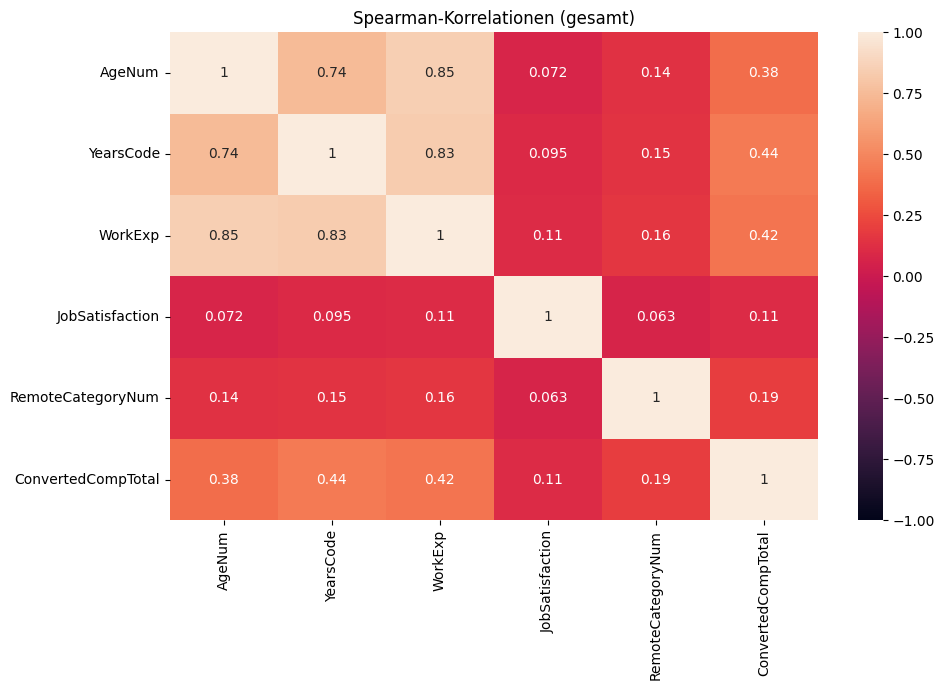

In [6]:
remote_map = {
    "Remote": 1,
    "In-person": 0,
    "Hybrid (some remote, leans heavy to in-person)": 0.25,
    "Hybrid (some in-person, leans heavy to flexibility)": 0.75,
    "Your choice (very flexible, you can come in when you want or just as needed)": 0.5
}
df["RemoteCategoryNum"] = df["RemoteWork"].map(remote_map)

cols = ["AgeNum", "YearsCode", "WorkExp", "JobSatisfaction", "RemoteCategoryNum", "ConvertedCompTotal"]
df_corr = df[cols].dropna(how="all")  # safety
plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(method="spearman"), annot=True, vmin=-1, vmax=1)
plt.title("Spearman-Korrelationen (gesamt)")
plt.tight_layout()
plt.show()

- Starke positive Korrelation zw. `AgeNum`, `YearsCode` und `WorkExp`
- fast keine Korrelation zw. `JobSatisfaction` und Alter bzw. `YearsCode` & `WorkExp`
    - Jobzufriedenheit zeigt kaum Zusammenhang mit `Alter`, `YearsCode` oder `WorkExp` ab
- `RemoteCategoryNum` korreliert ganz leicht positiv mit `AgeNum`, `YearsCode` und `WorkExp`
    - ältere und erfahrenere Entwickler tendieren schwach zu Remote/Flex
    - umgekehrt: jüngere Entwickler tendieren eher zu `In-Person` oder `In-Person-heavy` Hybrid (`RemoteCategoryNum` tendenziell niedriger)
- zudem korreliert `RemoteCategoryNum` leicht positiv mit `ConvertedCompTotal`
    - Remote/Flex ist tendenziell mit einer höheren Vergütung verbunden, jedoch sehr schwach
- Remote-Präferenz und `JobSatisfaction` hängen nur sehr schwach zusammen

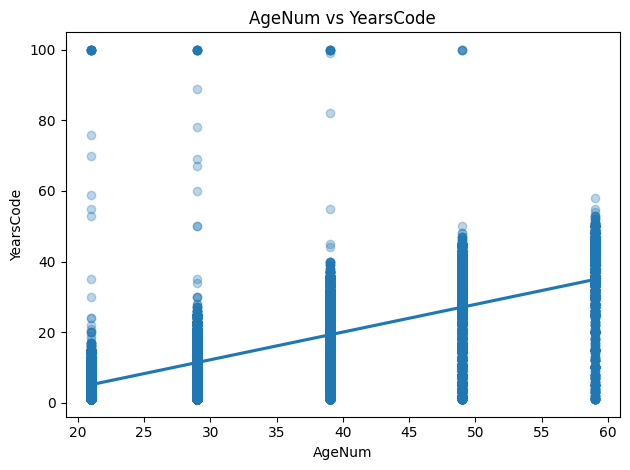

In [7]:
tmp = df[["AgeNum", "YearsCode"]].dropna()
sns.regplot(data=tmp, x="AgeNum", y="YearsCode", scatter_kws={"alpha": 0.3})
plt.title("AgeNum vs YearsCode")
plt.tight_layout()
plt.show()

- viele Ausreißer bzw. "Quatsch-Werte" hier vorhanden -> Plausabilitätsfilter einfügen

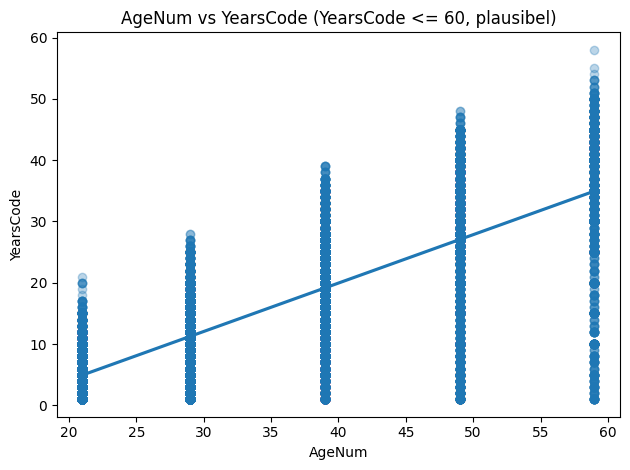

In [8]:
tmp = df[["AgeNum", "YearsCode"]].copy()
tmp["YearsCode"] = pd.to_numeric(tmp["YearsCode"], errors="coerce")
tmp = tmp.dropna(subset=["AgeNum", "YearsCode"])

# Plausibilitätsfilter
tmp = tmp[tmp["YearsCode"] <= 60]
tmp = tmp[tmp["YearsCode"] <= tmp["AgeNum"]]  # optional, aber sehr sinnvoll

sns.regplot(data=tmp, x="AgeNum", y="YearsCode", scatter_kws={"alpha": 0.3})
plt.title("AgeNum vs YearsCode (YearsCode <= 60, plausibel)")
plt.tight_layout()
plt.show()
# df

- mit höherem Alter steigt auch Programmiererfahrung im Schnitt (Trend-/Regressionsgerade)
- Werte wurden auf `YearsCode` <= 60 begrenzt und zusätzlich per Plausibilitätsfilter bereinigt, um Ausreißer zu entfernen
- innerhalb jeder Altersgruppe sind große Unterschiede sichtbar – Alter erklärt die Erfahrung nur teilweise

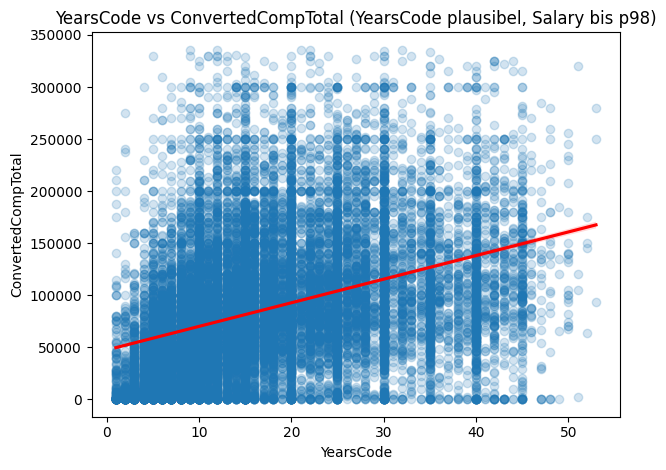

In [9]:
tmp = df[["AgeNum", "YearsCode", "ConvertedCompTotal"]].copy()
tmp["YearsCode"] = pd.to_numeric(tmp["YearsCode"], errors="coerce")
tmp["ConvertedCompTotal"] = pd.to_numeric(tmp["ConvertedCompTotal"], errors="coerce")
tmp = tmp.dropna(subset=["YearsCode", "ConvertedCompTotal"])

# Plausibilitätsfilter für YearsCode
tmp = tmp[tmp["YearsCode"] <= 60]
# optional (wenn AgeNum vorhanden und sinnvoll):
tmp = tmp.dropna(subset=["AgeNum"])
tmp = tmp[tmp["YearsCode"] <= tmp["AgeNum"]]

# Quantil-Cut nur fürs Gehalt (z.B. p98)
p98_comp = tmp["ConvertedCompTotal"].quantile(0.98)
tmp = tmp[tmp["ConvertedCompTotal"] <= p98_comp]

sns.regplot(
    data=tmp,
    x="YearsCode",
    y="ConvertedCompTotal",
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("YearsCode vs ConvertedCompTotal (YearsCode plausibel, Salary bis p98)")
plt.tight_layout()
plt.show()

- mit positiver Programmiererfahrung steig Gehalt (rote Regressionsgerade)
- bei gleicher Erfahrung gib es sehr unterschiedliche Gehälter - Erfahrung erklärt Gehalt nur teilweise
- `YearsCode` wurde plausibel begrenzt (<= 60 und <= AgeNum) und Gehälter obehalb der 98% Grenze entfernt, um Ausreißer zu entfernen

## Erstellen / Konvertieren Sie eine Time Series
- hier erstellen wir einen Zeiraum zwischen `start` und `end`, welche wir so gewählt haben, sodass der `CurrencyConverter` Werte zurückgibt, das haben wir durch simples ausprobieren so gewählt'
- wir definieren die fnktion `get_rates`, um für ein Datum den Wechselkurs der jeweiligen Währung zum US-Dollar über den `CurrencyConverter` abzurufen
- es werden die Wechselkurse für `EUR`, `GBP`, `INR`, `CAD` für jeden Tag ausgegeben und zwischengespeichert
    - es wurden genau diese 4 Währungen deshalb gewähl, da sie die Top 4 Währungen des Datensatzes sind, wie wir weiter oben herausgefunden haben
- daraus bauen wir eine TimeSeries, also ein DataFrame, mit Datum als Index und einer Spalte pro Währung (Wechselkurs zu USD)

In [10]:
# Wechselkurse analysieren
# Line Chart USD von jedem Tag

start = "2025-06-30"
end = "2025-11-03"

dates = pd.bdate_range(start, end)
# print (dates)

def get_rates(date, curr):
    cc = c.convert(1, curr, 'USD', date=date)
    return cc

rates = []

for d in dates:
    rate = get_rates(d, 'EUR')
    rates.append(rate)

frame = pd.DataFrame({'date': dates})
frame.set_index('date', inplace=True)

frame['EUR'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'GBP')
    rates.append(rate)

frame['GBP'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'INR')
    rates.append(rate)

frame['INR'] = rates

rates = []

for d in dates:
    rate = get_rates(d, 'CAD')
    rates.append(rate)

frame['CAD'] = rates


- wir plotten für jeden Subplot die Wechselkurs-Zeitreihe um uns die Entwicklung graphisch anzeigen zu lassen

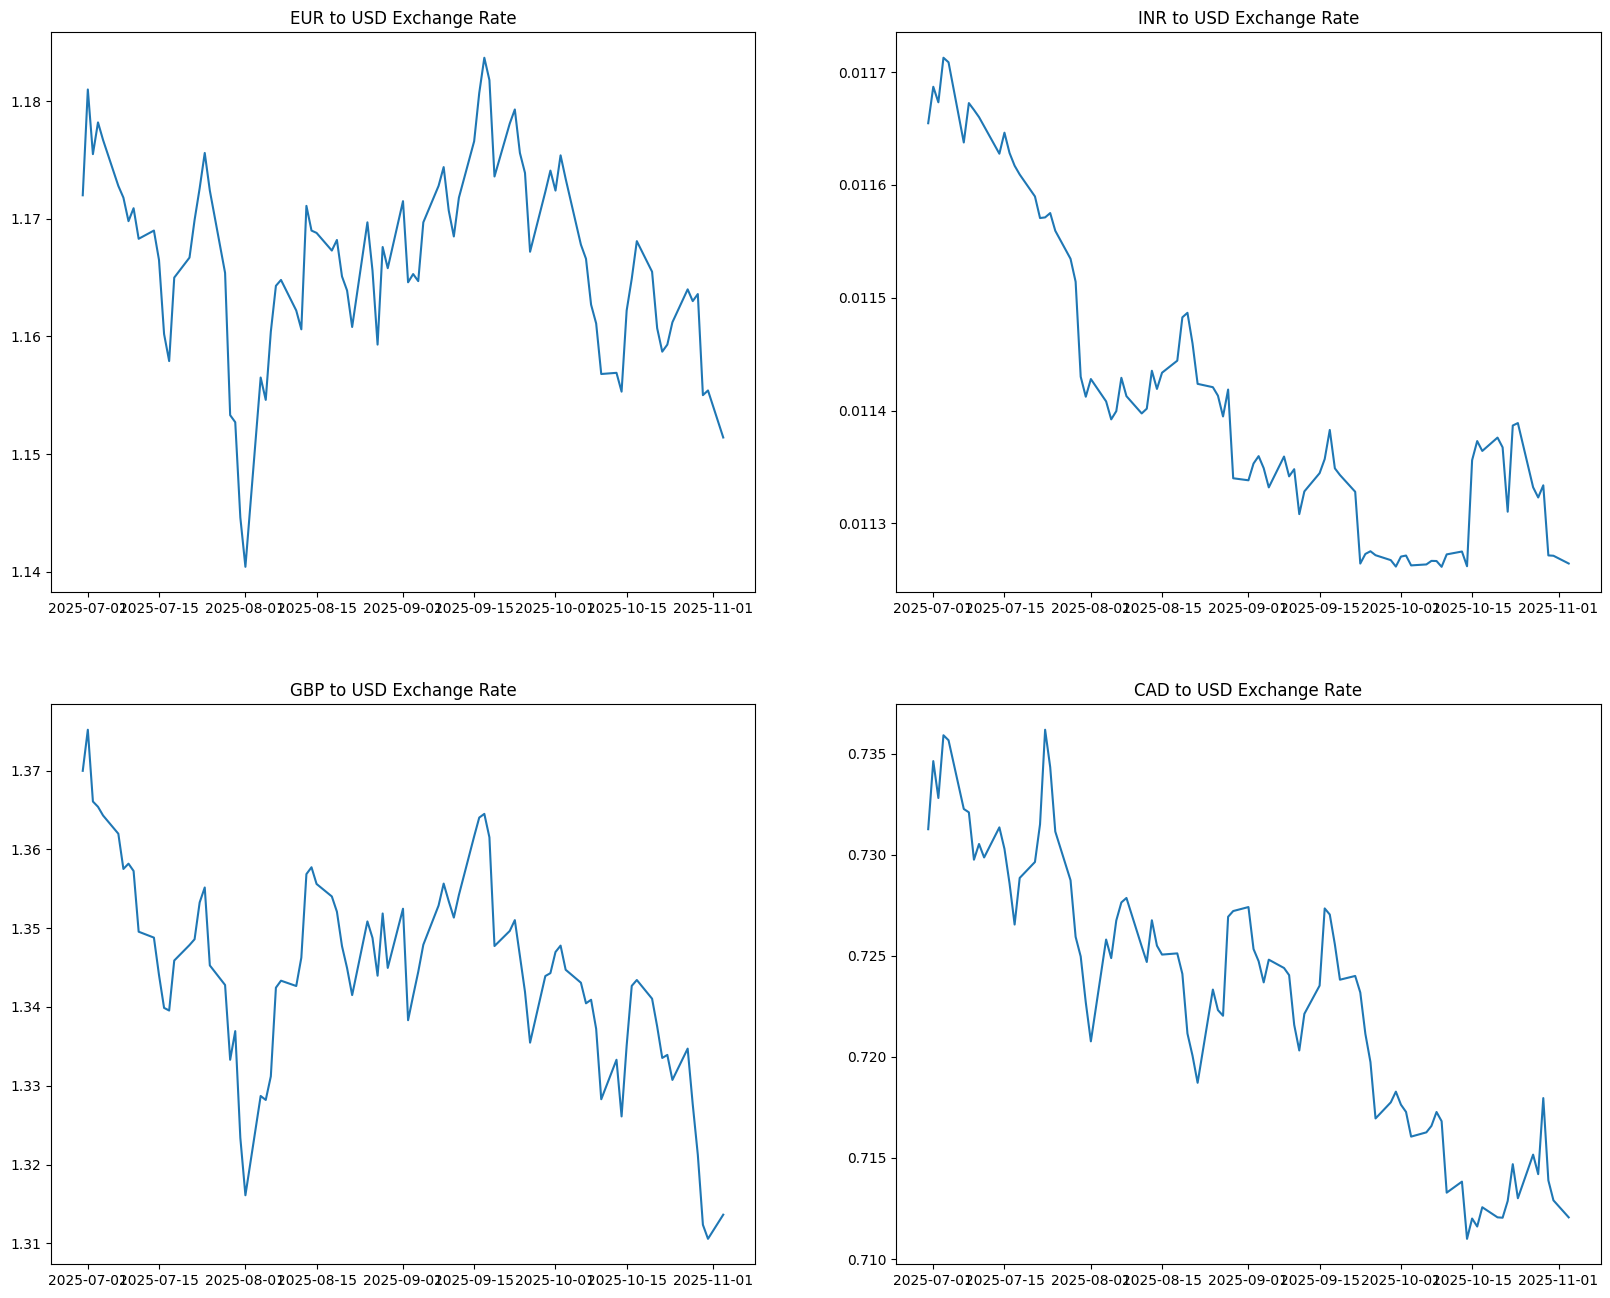

In [11]:
fig, ax = plt.subplots(2,2,figsize=(20, 16))

ax[0,0].set_title('EUR to USD Exchange Rate')
ax[0,0].plot(frame.index, frame['EUR'])

ax[0,1].set_title('INR to USD Exchange Rate')
ax[0,1].plot(frame.index, frame['INR'])

ax[1,0].set_title('GBP to USD Exchange Rate')
ax[1,0].plot(frame.index, frame['GBP'])

ax[1,1].set_title('CAD to USD Exchange Rate')
ax[1,1].plot(frame.index, frame['CAD'])

plt.show()


## Erstellen Sie eine Analyse basierend auf den Zeitdaten
- hier lassen wir uns wieder eine TimeSeries erstellen mit den Handelstagen und bauen den DataFrame mit den Wechselkursen der Top 4 Währungen zum USD auf
- berechnen der täglichen prozentualen Änderung
- messen der kurzfristigen Schwankungen (Volatilität) über rollierendes 7 Tage Fenster -> Standardabweichung der täglichen prozentualen Änderungen
- pro Tag wird ein Volatilitätsscore gebildet, indem Volatilität über alle 4 Währungen gemittelt wird
- der Tag mit dem geringsten Volatilitätsscore wird ausgegeben als Datum mit seinem Score ausgegeben und als empfohlener Stichtag genutzt

In [12]:
start = "2025-06-30"
end = "2025-11-03"

dates = pd.bdate_range(start, end)

def get_rates(date, curr):
    cc = c.convert(1, curr, 'USD', date=date)
    return cc

frame1 = pd.DataFrame({'date': dates}).set_index('date')

for curr in ['EUR', 'GBP', 'INR', 'CAD']:
    rates = []
    for d in dates:
        rates.append(get_rates(d, curr))
    frame1[curr] = rates

# Tag mit minimaler lokaler Volatilität

# tägliche prozentuale Änderungen (Returns)
returns = frame1[['EUR', 'GBP', 'INR', 'CAD']].pct_change()

# rollierende Standardabweichung über 7 Tage
window = 7
rolling_vol = returns.rolling(window=window, center=True).std()

# gemeinsamen Volatilitäts-Score pro Tag bilden
vol_score = rolling_vol.mean(axis=1)

# Tage ohne vollständige Daten entfernen
# vol_score = vol_score.dropna()

# Tag mit minimaler Volatilität bestimmen
best_date = vol_score.idxmin()
best_score = vol_score.loc[best_date]

print("Empfohlener Stichtag:", best_date.date())
print("Volatilitäts-Score an diesem Tag:", best_score)


Empfohlener Stichtag: 2025-10-06
Volatilitäts-Score an diesem Tag: 0.0013592461552492626


- da wir nun das neue Feature erstellt haben, werden die zuvor verwendeten Spalten nichtmehr benötigt, weshalb wir sie entfernen können

In [13]:
# Drop raw salary cols AFTER conversion
df = df.drop(columns=[c for c in ["CompTotal", "Currency", "ConvertedCompYearly", "ConvertedCompMonthly"] if c in df.columns], errors="ignore")
df.to_csv("output_woche4.csv")

In [14]:
df

,ResponseId,MainBranch,Age,EdLevel,Employment,Country,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,JobSatisfaction,AgeNum,ConvertedCompTotal,RemoteCategoryNum
0,1,I am a developer by profession,25-34 years old,Master’s degree,Employed,Ukraine,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",10.0,29.0,61659.84,1.00
1,2,I am a developer by profession,25-34 years old,Associate degree,Employed,Netherlands,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,9.0,29.0,105102.00,0.75
2,3,I am a developer by profession,35-44 years old,Bachelor’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",8.0,39.0,NaN,NaN
3,4,I am a developer by profession,35-44 years old,Bachelor’s degree,Employed,Ukraine,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",...,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,6.0,39.0,36435.36,1.00
4,5,I am a developer by profession,35-44 years old,Master’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,"Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,...,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",7.0,39.0,60000.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49118,49119,I am a developer by profession,25-34 years old,Bachelor’s degree,Employed,NaN,NaN,9.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,NaN,NaN,NaN,8.0,29.0,NaN,0.25
49119,49120,I am a developer by profession,35-44 years old,Bachelor’s degree,Employed,NaN,"Caring for dependents (children, elderly, etc.)",13.0,"No, I am not new to coding and did not learn n...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,NaN,0.25
49120,49121,I am a developer by profession,25-34 years old,Secondary school,Employed,NaN,NaN,2.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN
49121,49122,I am a developer by profession,25-34 years old,Associate degree,Employed,France,None of the above;Engaged in paid work (20-29 ...,10.0,"No, I am not new to coding and did not learn n...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,29.0,58390.00,0.25
